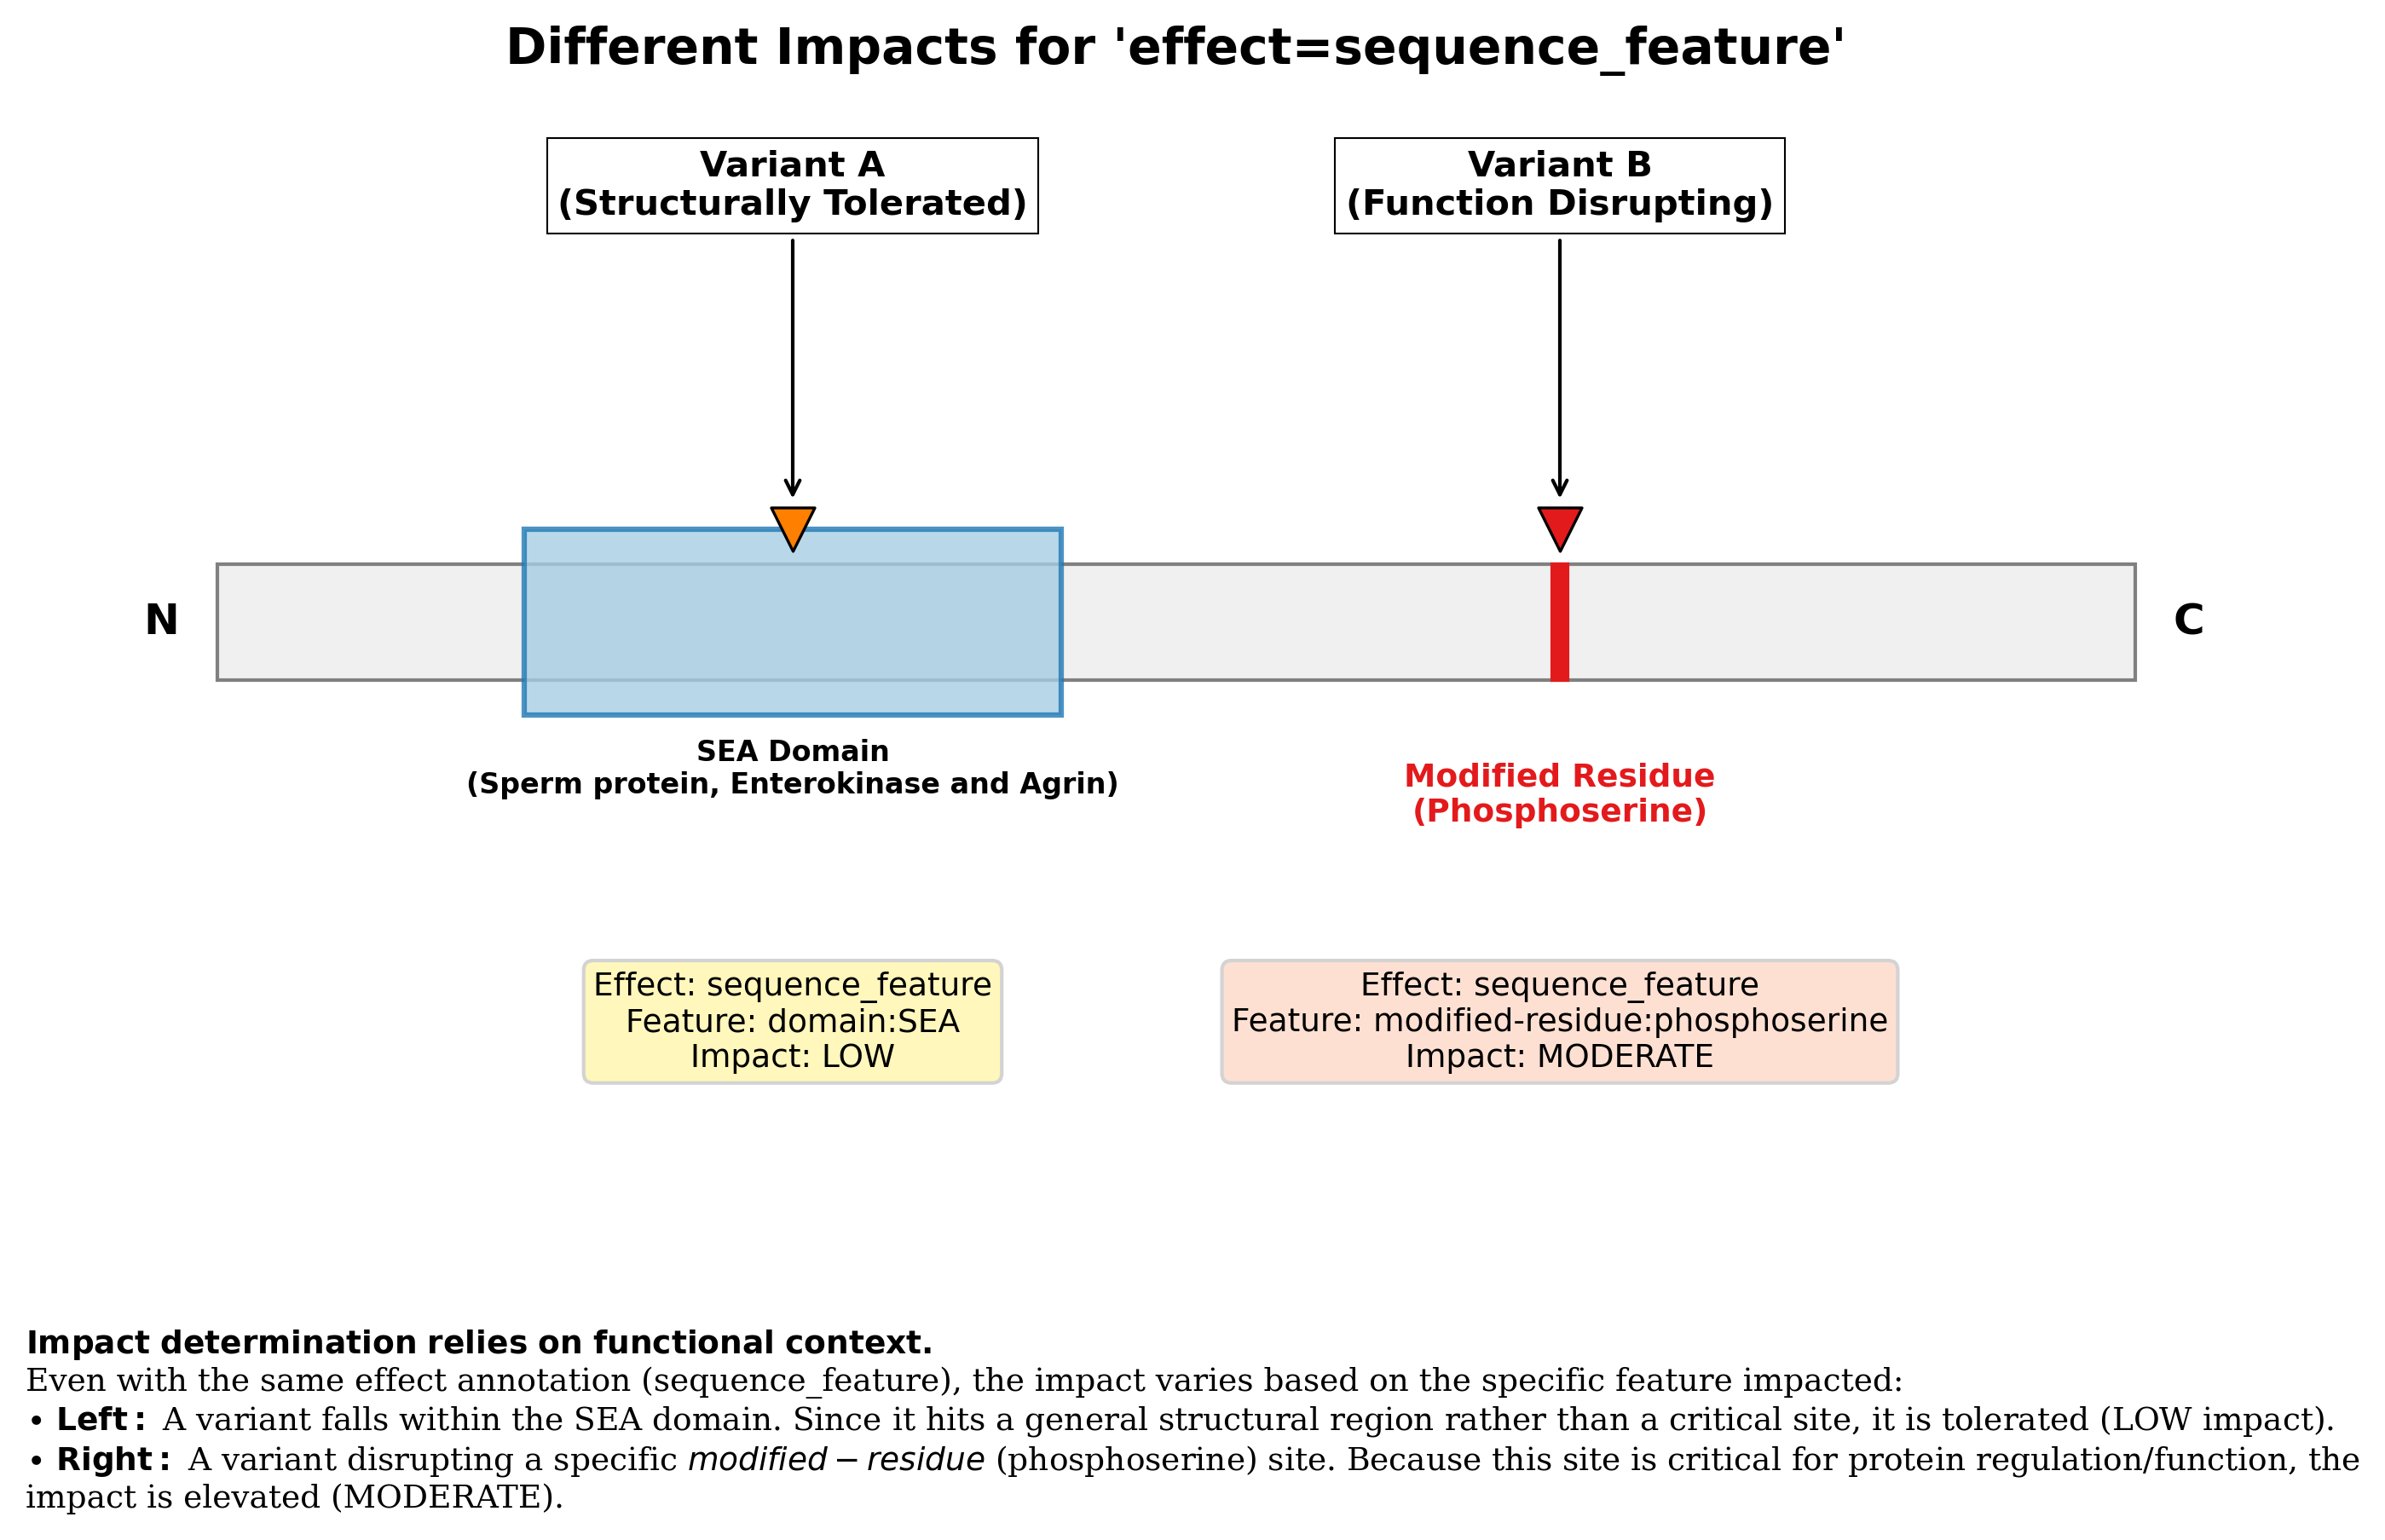

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap

# Set font to something standard for publications
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

def draw_protein_schematic():
    # Set up figure
    fig, ax = plt.subplots(figsize=(10, 6.5), dpi=300)
    
    # Define Academic/Colorblind-friendly Palette
    color_protein = '#f0f0f0'        # Light gray for backbone
    color_domain = '#a6cee3'         # Light blue for domain
    color_domain_border = '#1f78b4'  # Dark blue for domain border
    color_var_low = '#ff7f00'        # Orange for Low Impact
    color_var_mod = '#e31a1c'        # Red for Moderate Impact
    
    # 1. Protein Backbone
    # -----------------------
    protein_length = 500
    rect_backbone = patches.Rectangle((0, 0.45), protein_length, 0.1, 
                                      linewidth=1, edgecolor='gray', facecolor=color_protein, zorder=1)
    ax.add_patch(rect_backbone)
    
    # Termini labels
    ax.text(-10, 0.5, "N", va='center', ha='right', fontsize=12, fontweight='bold')
    ax.text(protein_length + 10, 0.5, "C", va='center', ha='left', fontsize=12, fontweight='bold')

    # 2. Scenario A: LOW Impact Example (AGRN Gene)
    # ----------------------------------------
    domain_start = 80
    domain_end = 220
    rect_domain = patches.Rectangle((domain_start, 0.42), domain_end - domain_start, 0.16, 
                                    linewidth=1.5, edgecolor=color_domain_border, facecolor=color_domain, alpha=0.8, zorder=2)
    ax.add_patch(rect_domain)
    # Label
    ax.text((domain_start+domain_end)/2, 0.40, "SEA Domain\n(Sperm protein, Enterokinase and Agrin)", 
            ha='center', va='top', fontsize=8, color='black', fontweight='bold', zorder=3)
    
    # Variant A Marker (Inverted Triangle)
    variant_a_pos = 150
    ax.scatter([variant_a_pos], [0.58], s=150, marker='v', 
               color=color_var_low, edgecolors='black', linewidth=0.8, zorder=10)
    
    # Annotation A (Top)
    ax.annotate('Variant A\n(Structurally Tolerated)', 
                xy=(variant_a_pos, 0.60), xytext=(variant_a_pos, 0.85),
                arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3", lw=1),
                ha='center', fontsize=10, fontweight='bold', zorder=100,
                bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", lw=0.5))

    # Description A (Bottom) - Using specific info from VCF
    ax.text(variant_a_pos, 0.20, "Effect: sequence_feature\nFeature: domain:SEA\nImpact: LOW", 
            ha='center', va='top', fontsize=9, color='black',
            bbox=dict(boxstyle="round,pad=0.3", fc="#fff7bc", ec="lightgray", alpha=1.0, zorder=20))


    # 3. Scenario B: MODERATE Impact Example (Specific Site)
    # -------------------------------------------------------
    site_pos = 350
    
    # Visualizing the active site
    rect_site = patches.Rectangle((site_pos-2, 0.45), 4, 0.1, 
                                  color=color_var_mod, zorder=3)
    ax.add_patch(rect_site)

    ax.text(site_pos, 0.38, "Modified Residue\n(Phosphoserine)", 
            ha='center', va='top', fontsize=9, color=color_var_mod, fontweight='bold')

    # Variant B Marker - Inverted Triangle ('v'), Red
    variant_b_pos = 350
    ax.scatter([variant_b_pos], [0.58], s=150, marker='v', 
               color=color_var_mod, edgecolors='black', linewidth=0.8, zorder=10)
    
    # Annotation B (Top)
    ax.annotate('Variant B\n(Function Disrupting)', 
                xy=(variant_b_pos, 0.60), xytext=(variant_b_pos, 0.85),
                arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3", lw=1),
                ha='center', fontsize=10, fontweight='bold', zorder=100,
                bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", lw=0.5))

    # Description B (Bottom) - Using specific info
    ax.text(variant_b_pos, 0.20, "Effect: sequence_feature\nFeature: modified-residue:phosphoserine\nImpact: MODERATE", 
            ha='center', va='top', fontsize=9, color='black',
            bbox=dict(boxstyle="round,pad=0.3", fc="#fee0d2", ec="lightgray", alpha=1.0, zorder=20))

    # 4. Final Formatting & Legend
    # --------------------
    ax.set_xlim(-50, protein_length + 50)
    ax.set_ylim(0, 1.0)
    ax.axis('off')
    
    # Title
    ax.text(protein_length/2, 0.98, "Different Impacts for 'effect=sequence_feature'", 
            ha='center', fontsize=14, fontweight='bold', color='black')
    
    # Description Text 
    # Removed manual newlines to allow text to fill the line (simulating Justified/Block look)
    # Enabling wrap=True to handle overflow if font/dpi scaling varies.
    caption_text = (
        r"$\bf{Impact\ determination\ relies\ on\ functional\ context.}$ " + "\n"
        "Even with the same effect annotation (sequence_feature), the impact varies based on the specific feature impacted:\n"
        r"$\bullet$ $\bf{Left:}$ A variant falls within the SEA domain. Since it hits a general structural region rather than a critical site, it is tolerated (LOW impact)." + "\n"
        r"$\bullet$ $\bf{Right:}$ A variant disrupting a specific $\it{modified-residue}$ (phosphoserine) site. Because this site is critical for protein regulation/function, the impact is elevated (MODERATE)."
    )
    
    # Place caption at the bottom with wrap=True (Figure coordinates)
    # ha='left' aligns the start of the lines. Since the lines are long, they will span the figure.
    plt.figtext(0.05, 0.02, caption_text, ha="left", fontsize=9, family='serif',
                bbox={"facecolor":"white", "alpha":0, "pad":5}, wrap=True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.20, left=0.05, right=0.95)
    plt.show()

if __name__ == "__main__":
    draw_protein_schematic()